In [15]:
# Basic
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# TensorFlow / Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# For prediction
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping


In [16]:
# Train generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (ONLY rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train
train_data = train_datagen.flow_from_directory(
    "Dataset2/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Validation
val_data = val_test_datagen.flow_from_directory(
    "Dataset2/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Test
test_data = val_test_datagen.flow_from_directory(
    "Dataset2/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # important for evaluation
)

Found 2043 images belonging to 6 classes.
Found 439 images belonging to 6 classes.
Found 441 images belonging to 6 classes.


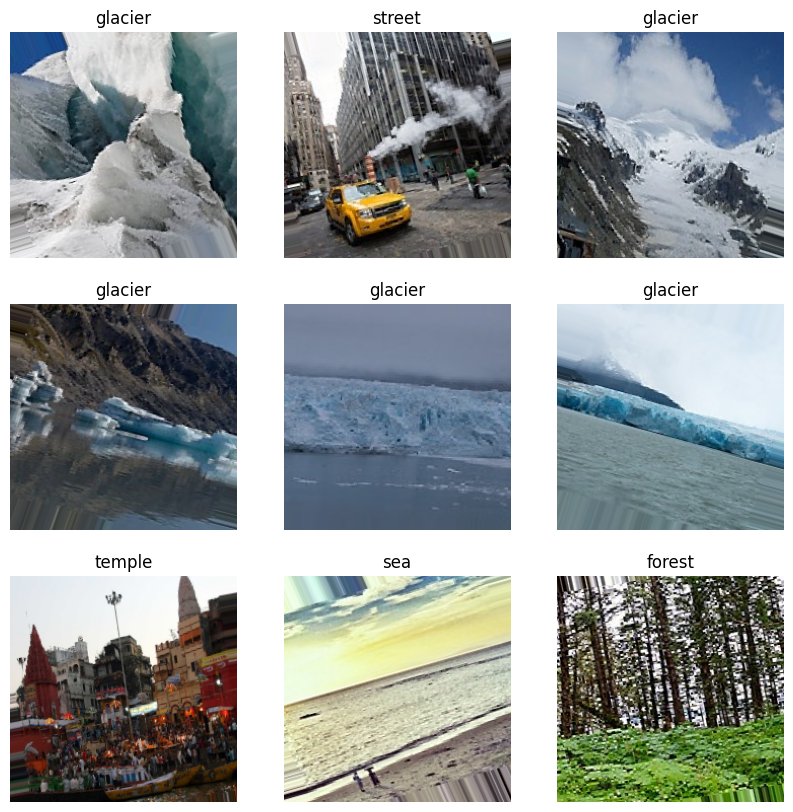

In [17]:
images, labels = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()])
    plt.axis('off')

plt.show()

In [18]:
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:


history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=13
)

Epoch 1/13
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 481ms/step - accuracy: 0.3965 - loss: 1.4773 - val_accuracy: 0.4761 - val_loss: 1.4421
Epoch 2/13
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 482ms/step - accuracy: 0.5213 - loss: 1.2127 - val_accuracy: 0.5626 - val_loss: 1.0715
Epoch 3/13
50/64 ━━━━━━━━━━━━━━━━━━━━ 6s 471ms/step - accuracy: 0.5273 - loss: 1.1535

KeyboardInterrupt: 

In [14]:
# Train generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (ONLY rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train
train_data = train_datagen.flow_from_directory(
    "Dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Validation
val_data = val_test_datagen.flow_from_directory(
    "Dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Test
test_data = val_test_datagen.flow_from_directory(
    "Dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # important for evaluation
)


model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=13
)

Found 420 images belonging to 6 classes.
Found 90 images belonging to 6 classes.


Found 90 images belonging to 6 classes.


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 424ms/step - accuracy: 0.2024 - loss: 1.7799 - val_accuracy: 0.3889 - val_loss: 1.6021
Epoch 2/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 417ms/step - accuracy: 0.3310 - loss: 1.5331 - val_accuracy: 0.5111 - val_loss: 1.2620
Epoch 3/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 421ms/step - accuracy: 0.4429 - loss: 1.3766 - val_accuracy: 0.6222 - val_loss: 1.0199
Epoch 4/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step - accuracy: 0.4595 - loss: 1.2912 - val_accuracy: 0.5556 - val_loss: 1.0946
Epoch 5/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 413ms/step - accuracy: 0.5357 - loss: 1.1908 - val_accuracy: 0.6333 - val_loss: 0.9064
Epoch 6/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 464ms/step - accuracy: 0.5357 - loss: 1.1429 - val_accuracy: 0.6778 - val_loss: 0.8066
Epoch 7/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.5690 - loss: 1.0846 - val_accuracy: 0.6111 - val_loss: 0.9210
Epoch 8/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step - accuracy: 0.5667 - loss: 1.0974 - val_accuracy: 0.

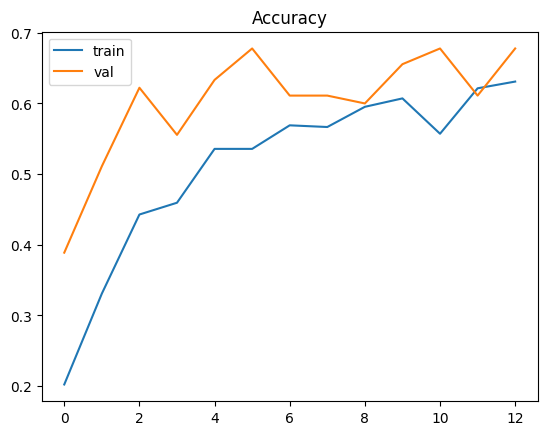

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


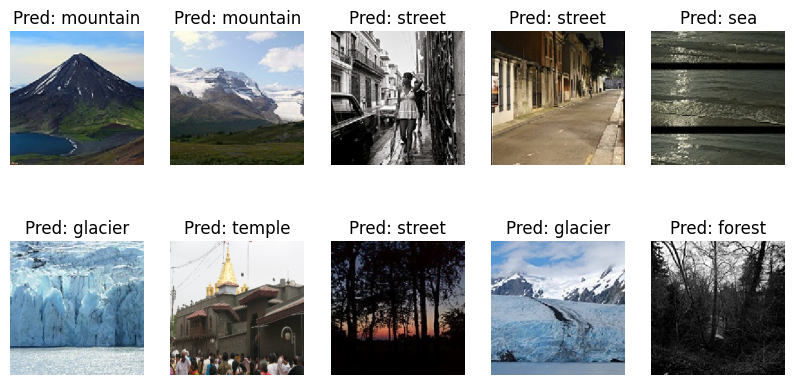

In [12]:
all_images = []

dataset_path = "Dataset2/test"

for category in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, category)
    if os.path.isdir(folder):
        for img in os.listdir(folder):
            all_images.append(os.path.join(folder, img))

# pick 3 random images
random_images = random.sample(all_images, 10)


class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,5))

for i, img_path in enumerate(random_images):
    
    # load image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]

    # show image
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')

plt.show()